Running simulation: Dominant
Running simulation: Heterozygous
Running simulation: Homozygous
Running simulation: Recessive


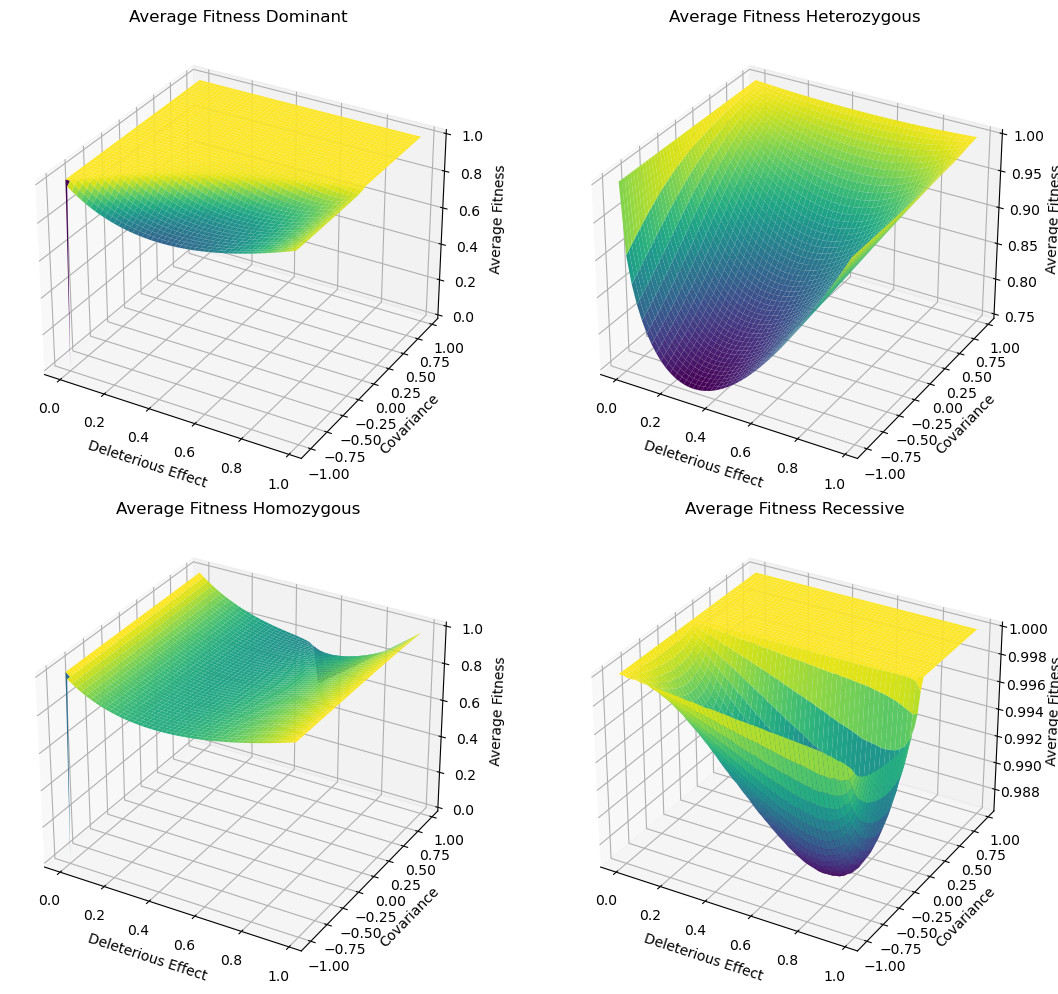

In [3]:
from pop_gen import PopGen
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
populations = 50
generations = 100

# Create a grid of covariance and deleterious effect values
covariances = [((i / populations) * 2) - 1 for i in range(populations)]
deleteriouses = [i / populations for i in range(populations)]

# Function to run the simulation and get average fitness values
def run_simulation(genotype_data_func):
    average_fitnesses = np.zeros((populations, populations))
    for i, c in enumerate(covariances):
        for j, d in enumerate(deleteriouses):
            
            # Simulation parameters
            pg = PopGen()
            pg.genotype_data = genotype_data_func(c, d)
            pg.growth_rate = 0.1
            pg.carrying_capacity = 20000
            pg.mutation_rate = 0.01
            pg.run(generations)

            # Store the average fitness
            average_fitnesses[i, j] = pg.get_last_average_fitness()
    return average_fitnesses

# Genotype data functions for each scenario
def genotype_dominant(c, d):
    return {
        (('A1', 'A1'),): {'Nm': 250, 'Nf': 250, 'Wm': d, 'Wf': d, 'covariance': c},
        (('A1', 'A2'),): {'Nm': 500, 'Nf': 500, 'Wm': d, 'Wf': d, 'covariance': c},
        (('A2', 'A2'),): {'Nm': 250, 'Nf': 250, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c}
    }

def genotype_heterozygous(c, d):
    return {
        (('A1', 'A1'),): {'Nm': 250, 'Nf': 250, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c},
        (('A1', 'A2'),): {'Nm': 500, 'Nf': 500, 'Wm': d, 'Wf': d, 'covariance': c},
        (('A2', 'A2'),): {'Nm': 250, 'Nf': 250, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c}
    }

def genotype_homozygous(c, d):
    return {
        (('A1', 'A1'),): {'Nm': 250, 'Nf': 250, 'Wm': d, 'Wf': d, 'covariance': c},
        (('A1', 'A2'),): {'Nm': 500, 'Nf': 500, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c},
        (('A2', 'A2'),): {'Nm': 250, 'Nf': 250, 'Wm': d, 'Wf': d, 'covariance': c}
    }

def genotype_recessive(c, d):
    return {
        (('A1', 'A1'),): {'Nm': 250, 'Nf': 250, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c},
        (('A1', 'A2'),): {'Nm': 500, 'Nf': 500, 'Wm': 1.0, 'Wf': 1.0, 'covariance': c},
        (('A2', 'A2'),): {'Nm': 250, 'Nf': 250, 'Wm': d, 'Wf': d, 'covariance': c}
    }

# Run simulations for each scenario
print('Running simulation: Dominant', flush=True)
average_fitness_dominant = run_simulation(genotype_dominant)

print('Running simulation: Heterozygous', flush=True)
average_fitness_heterozygous = run_simulation(genotype_heterozygous)

print('Running simulation: Homozygous', flush=True)
average_fitness_homozygous = run_simulation(genotype_homozygous)

print('Running simulation: Recessive', flush=True)
average_fitness_recessive = run_simulation(genotype_recessive)

# Prepare data for 3D plotting
X, Y = np.meshgrid(deleteriouses, covariances)

# Create a 2x2 grid of 3D plots
fig = plt.figure(figsize=(12, 10))

# Plot 1: Dominant
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot_surface(X, Y, average_fitness_dominant, cmap='viridis')
ax1.set_title('Average Fitness for Deleterious Dominant')
ax1.set_xlabel('Deleterious Effect')
ax1.set_ylabel('Covariance')
ax1.set_zlabel('Average Fitness')

# Plot 2: Heterozygous
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_surface(X, Y, average_fitness_heterozygous, cmap='viridis')
ax2.set_title('Average Fitness for Deleterious Heterozygote')
ax2.set_xlabel('Deleterious Effect')
ax2.set_ylabel('Covariance')
ax2.set_zlabel('Average Fitness')

# Plot 3: Homozygous
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(X, Y, average_fitness_homozygous, cmap='viridis')
ax3.set_title('Average Fitness for Deleterious Homozygote')
ax3.set_xlabel('Deleterious Effect')
ax3.set_ylabel('Covariance')
ax3.set_zlabel('Average Fitness')

# Plot 4: Recessive
ax4 = fig.add_subplot(224, projection='3d')
ax4.plot_surface(X, Y, average_fitness_recessive, cmap='viridis')
ax4.set_title('Average Fitness for Deleterious Recessive')
ax4.set_xlabel('Deleterious Effect')
ax4.set_ylabel('Covariance')
ax4.set_zlabel('Average Fitness')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
